In [1]:
#Water Potability
#Prasad Rajesh Posture
#UID No. 19BSC049 | Roll No. 47 | TYBSC (AY 2021-22) | Jai Hind College (Mumbai)

In [5]:
#Introduction
#Access of potable water i.e. the water that isn't harmful for our health is a basic human right.
#However, the availablity of potable water is still a topic of discussion in every corner of the world. 
#In this project I'm trying to figure out what are the factors that majorly affect the potability of water
#and at the end I'll a write a machine learning algorithm which will predict whether the water is safe for 
#drinking or not. Later I will use the trained and tuned model for making a user friendly web application 
#where the user can change value of different constituents and will get the potability as the output.
# ==============================
# ==============================
# ==============================
# ==============================
# 1. Imports
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# ==============================
# 3. Clean Column Names
# ==============================
df.columns = df.columns.str.strip()
print("Columns:\n", df.columns)

# ==============================
# 4. Target
# ==============================
target_col = 'Calories'   # keep this if correct

X = df.drop(target_col, axis=1)
y = df[target_col]

# ==============================
# 5. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 6. Scaling (important for SVR & Linear)
# ==============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 7. Models (REGRESSORS)
# ==============================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "XGBoost": XGBRegressor()
}

# ==============================
# 8. Train & Evaluate
# ==============================
results = {}

for name, model in models.items():
    
    if name in ["Linear Regression", "SVR"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {"R2": r2, "MAE": mae}
    
    print(f"{name} -> R2: {r2:.3f}, MAE: {mae:.2f}")

# ==============================
# 9. Final Results
# ==============================
print("\nFinal Comparison:")
print(results)

Columns:
 Index(['User_ID', 'Calories'], dtype='object')
Linear Regression -> R2: -0.001, MAE: 53.93
Random Forest -> R2: -0.499, MAE: 63.05
SVR -> R2: -0.047, MAE: 53.88
XGBoost -> R2: -0.022, MAE: 54.40

Final Comparison:
{'Linear Regression': {'R2': -0.0014323927992658803, 'MAE': 53.93364822763257}, 'Random Forest': {'R2': -0.49928420201873935, 'MAE': 63.04677157936508}, 'SVR': {'R2': -0.04662535270308976, 'MAE': 53.879330929908726}, 'XGBoost': {'R2': -0.021812551181249917, 'MAE': 54.40185835520426}}


In [7]:
#Column Description
#pH value: PH is an important parameter in evaluating the acid–base balance of water. It is also the indicator of acidic or alkaline condition of water status. WHO has recommended maximum permissible limit of pH from 6.5 to 8.5. The current investigation ranges were 6.52–6.83 which are in the range of WHO standards.
#Hardness: Hardness is mainly caused by calcium and magnesium salts. These salts are dissolved from geologic deposits through which water travels. The length of time water is in contact with hardness producing material helps determine how much hardness there is in raw water. Hardness was originally defined as the capacity of water to precipitate soap caused by Calcium and Magnesium.
#Solids (Total dissolved solids - TDS): Water has the ability to dissolve a wide range of inorganic and some organic minerals or salts such as potassium, calcium, sodium, bicarbonates, chlorides, magnesium, sulfates etc. These minerals produced un-wanted taste and diluted color in appearance of water. This is the important parameter for the use of water. The water with high TDS value indicates that water is highly mineralized. 
#Desirable limit for TDS is 500 mg/l and maximum limit is 1000 mg/l which prescribed for drinking purpose.
#Chloramines: Chlorine and chloramine are the major disinfectants used in public water systems. Chloramines are most commonly formed when ammonia is added to chlorine to treat drinking water. Chlorine levels up to 4 milligrams per liter (mg/L or 4 parts per million (ppm)) are considered safe in drinking water.
#Sulfate: Sulfates are naturally occurring substances that are found in minerals, soil, and rocks. They are present in ambient air, groundwater, plants, and food. The principal commercial use of sulfate is in the chemical industry. Sulfate concentration in seawater is about 2,700 milligrams per liter (mg/L). It ranges from 3 to 30 mg/L in most freshwater supplies, although much higher concentrations (1000 mg/L) are found in some geographic locations.
#Conductivity: Pure water is not a good conductor of electric current rather’s a good insulator. Increase in ions concentration enhances the electrical conductivity of water. Generally, the amount of dissolved solids in water determines the electrical conductivity. Electrical conductivity (EC) actually measures the ionic process of a solution that enables it to transmit current. According to WHO standards, EC value should not exceeded 400 μS/cm.
#Organic_carbon: Total Organic Carbon (TOC) in source waters comes from decaying natural organic matter (NOM) as well as synthetic sources. TOC is a measure of the total amount of carbon in organic compounds in pure water. According to US EPA < 2 mg/L as TOC in treated / drinking water, and < 4 mg/Lit in source water which is use for treatment.
#Trihalomethanes: THMs are chemicals which may be found in water treated with chlorine. The concentration of THMs in drinking water varies according to the level of organic material in the water, the amount of chlorine required to treat the water, and the temperature of the water that is being treated. THM levels up to 80 ppm is considered safe in drinking water.
#Turbidity: The turbidity of water depends on the quantity of solid matter present in the suspended state. It is a measure of light emitting properties of water and the test is used to indicate the quality of waste discharge with respect to colloidal matter. The mean turbidity value obtained for Wondo Genet Campus (0.98 NTU) is lower than the WHO recommended value of 5.00 NTU.
#Potability: Indicates if water is safe for human consumption where 1 means Potable and 0 means Not potable.
#Turbidity: The turbidity of water depends on the quantity of solid matter present in the suspended state. It is a measure of light emitting properties of water and the test is used to indicate the quality of waste discharge with respect to colloidal matter. The mean turbidity value obtained for Wondo Genet Campus (0.98 NTU) is lower than the WHO recommended value of 5.00 NTU.
#Potability: Indicates if water is safe for human consumption where 1 means Potable and 0 means Not potable.
#Exploratory Data Analysis
print(df.shape)   # (rows, columns)

(15000, 2)


In [9]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# ==============================
# 3. Basic EDA
# ==============================
print("Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nInfo:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ==============================
# 4. Clean Column Names
# ==============================
df.columns = df.columns.str.strip()

# ==============================
# 5. Select Target Column
# ==============================
target_col = 'Calories'   # 🔴 Change if needed

# ==============================
# 6. Features & Target
# ==============================
X = df.drop(target_col, axis=1)
y = df[target_col]

# ==============================
# 7. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 8. Scaling
# ==============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 9. Models (Regression)
# ==============================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "XGBoost": XGBRegressor()
}

# ==============================
# 10. Train & Evaluate
# ==============================
results = {}

for name, model in models.items():
    
    if name in ["Linear Regression", "SVR"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {"R2": r2, "MAE": mae}
    
    print(f"{name} -> R2: {r2:.3f}, MAE: {mae:.2f}")

# ==============================
# 11. Final Results
# ==============================
print("\nFinal Comparison:")
print(results)

Shape: (15000, 2)

Columns: Index(['User_ID', 'Calories'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB

Missing Values:
User_ID     0
Calories    0
dtype: int64

Statistical Summary:
            User_ID      Calories
count  1.500000e+04  15000.000000
mean   1.497736e+07     89.539533
std    2.872851e+06     62.456978
min    1.000116e+07      1.000000
25%    1.247419e+07     35.000000
50%    1.499728e+07     79.000000
75%    1.744928e+07    138.000000
max    1.999965e+07    314.000000
Linear Regression -> R2: -0.001, MAE: 53.93
Random Forest -> R2: -0.499, MAE: 63.05
SVR -> R2: -0.047, MAE: 53.88
XGBoost -> R2: -0.022, MAE: 54.40

Final Comparison:
{'Linear Regression': {'R2': -0.00143239279926588

In [11]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB


,User_ID,Calories
count,1.500000e+04,15000.000000
mean,1.497736e+07,89.539533
std,2.872851e+06,62.456978
min,1.000116e+07,1.000000
25%,1.247419e+07,35.000000
50%,1.499728e+07,79.000000
75%,1.744928e+07,138.000000
max,1.999965e+07,314.000000


In [12]:
train_df = df.copy()

# Statistical Information
train_df.describe()

,User_ID,Calories
count,1.500000e+04,15000.000000
mean,1.497736e+07,89.539533
std,2.872851e+06,62.456978
min,1.000116e+07,1.000000
25%,1.247419e+07,35.000000
50%,1.499728e+07,79.000000
75%,1.744928e+07,138.000000
max,1.999965e+07,314.000000


Shape: (15000, 2)

Columns: Index(['User_ID', 'Calories'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB

Missing Values:
User_ID     0
Calories    0
dtype: int64

Statistical Summary:
            User_ID      Calories
count  1.500000e+04  15000.000000
mean   1.497736e+07     89.539533
std    2.872851e+06     62.456978
min    1.000116e+07      1.000000
25%    1.247419e+07     35.000000
50%    1.499728e+07     79.000000
75%    1.744928e+07    138.000000
max    1.999965e+07    314.000000


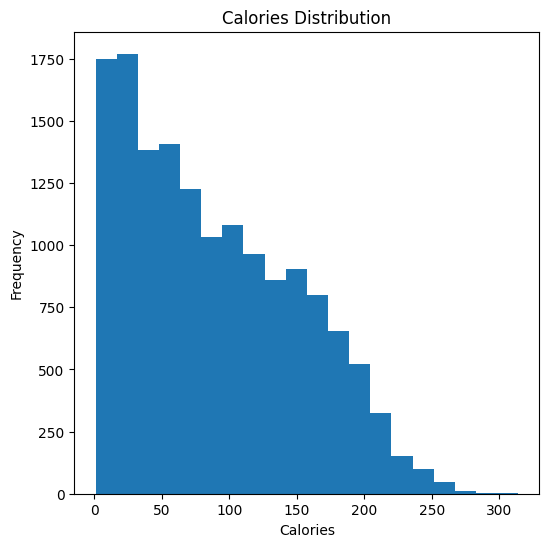

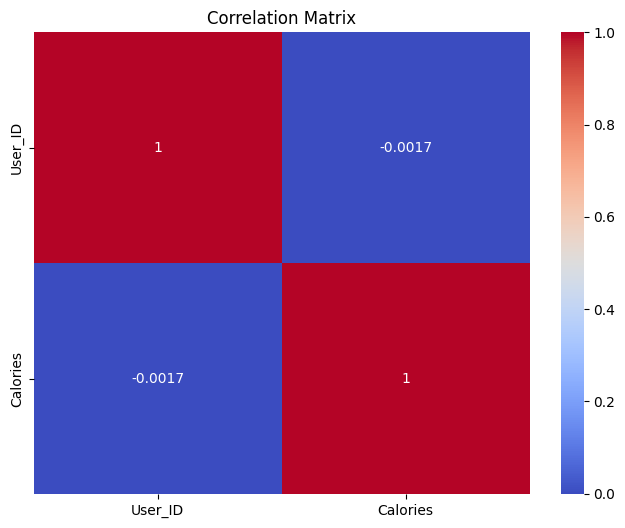

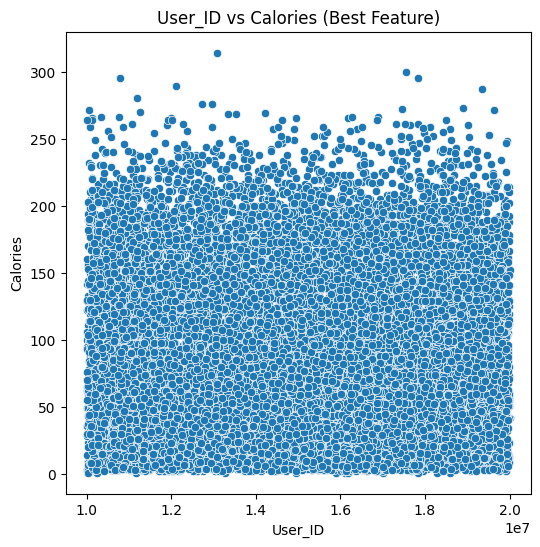

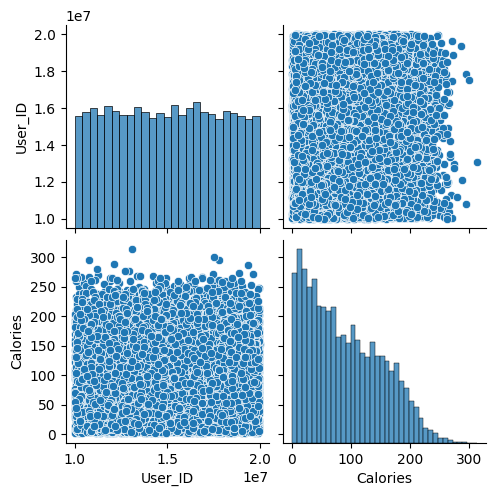

Linear Regression -> R2: -0.001, MAE: 53.93
Random Forest -> R2: -0.499, MAE: 63.05
SVR -> R2: -0.047, MAE: 53.88
XGBoost -> R2: -0.022, MAE: 54.40


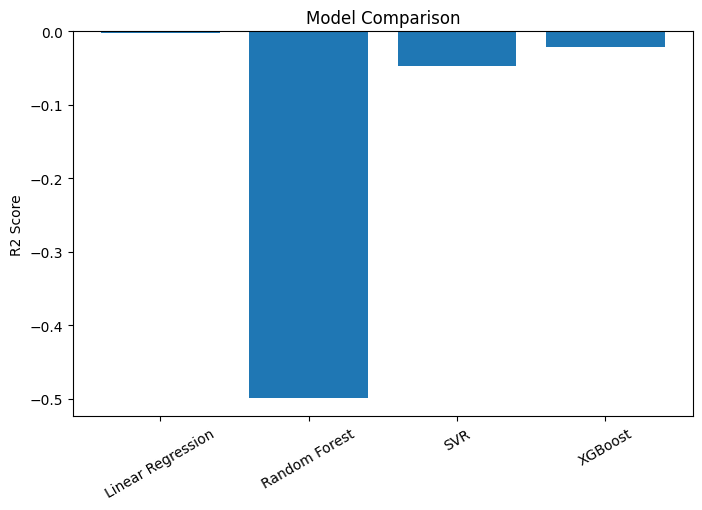


Final Results:
{'Linear Regression': {'R2': -0.0014323927992658803, 'MAE': 53.93364822763257}, 'Random Forest': {'R2': -0.49928420201873935, 'MAE': 63.04677157936508}, 'SVR': {'R2': -0.04662535270308976, 'MAE': 53.879330929908726}, 'XGBoost': {'R2': -0.021812551181249917, 'MAE': 54.40185835520426}}


In [17]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# ==============================
# 3. Basic EDA
# ==============================
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nInfo:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ==============================
# 4. Visualization
# ==============================

# Histogram
plt.figure(figsize=(6,6))
plt.hist(df['Calories'], bins=20)
plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Best Feature Scatter Plot (AUTO FIX)
corr = df.corr(numeric_only=True)['Calories'].sort_values(ascending=False)
best_feature = corr.index[1]

plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x=best_feature, y='Calories')
plt.title(f"{best_feature} vs Calories (Best Feature)")
plt.show()

# Pairplot (optional but useful)
sns.pairplot(df)
plt.show()

# ==============================
# 5. Features & Target
# ==============================
target_col = 'Calories'

X = df.drop(target_col, axis=1)
y = df[target_col]

# ==============================
# 6. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 7. Scaling
# ==============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 8. Models
# ==============================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "XGBoost": XGBRegressor()
}

# ==============================
# 9. Train & Evaluate
# ==============================
results = {}

for name, model in models.items():
    
    if name in ["Linear Regression", "SVR"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {"R2": r2, "MAE": mae}
    
    print(f"{name} -> R2: {r2:.3f}, MAE: {mae:.2f}")

# ==============================
# 10. Model Comparison Plot
# ==============================
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [v['R2'] for v in results.values()])
plt.xticks(rotation=30)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

print("\nFinal Results:")
print(results)

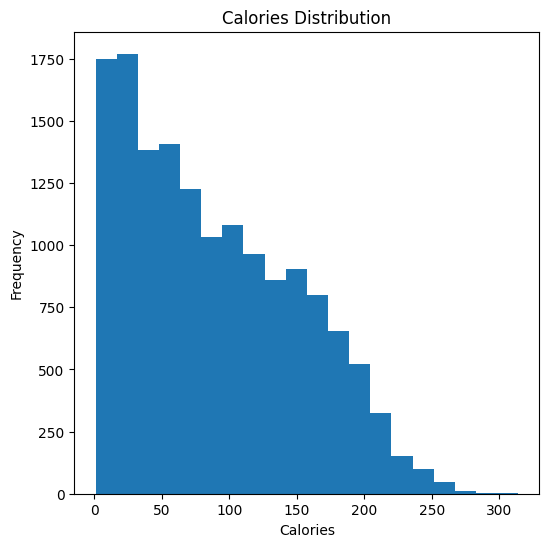

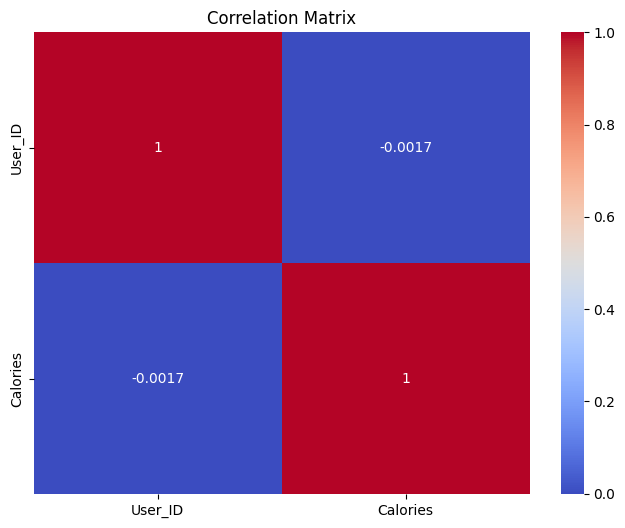

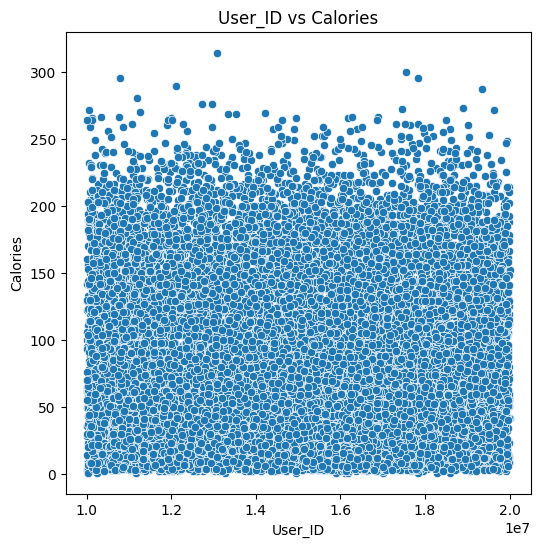

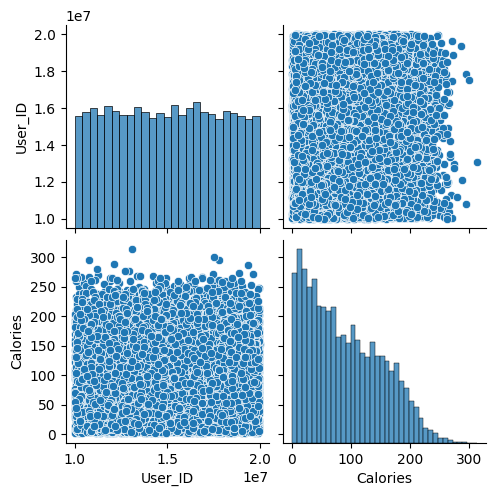

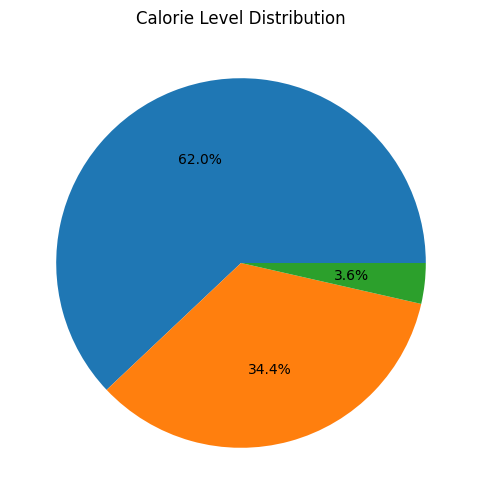

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. Histogram (Calories Distribution)
# ==============================
plt.figure(figsize=(6,6))
plt.hist(df['Calories'], bins=20)

plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()


# ==============================
# 2. Correlation Heatmap
# ==============================
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()


# ==============================
# 3. Best Feature vs Calories (AUTO)
# ==============================
corr = df.corr(numeric_only=True)['Calories'].sort_values(ascending=False)
best_feature = corr.index[1]

plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x=best_feature, y='Calories')

plt.title(f"{best_feature} vs Calories")
plt.show()


# ==============================
# 4. Pairplot (All Relationships)
# ==============================
sns.pairplot(df)
plt.show()


# ==============================
# 5. OPTIONAL Pie Chart (Categorized Calories)
# ==============================
df['Calorie_Level'] = pd.cut(df['Calories'], bins=3, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(6,6))
plt.pie(
    df['Calorie_Level'].value_counts(),
    autopct="%1.1f%%"
)

plt.title("Calorie Level Distribution")
plt.show()

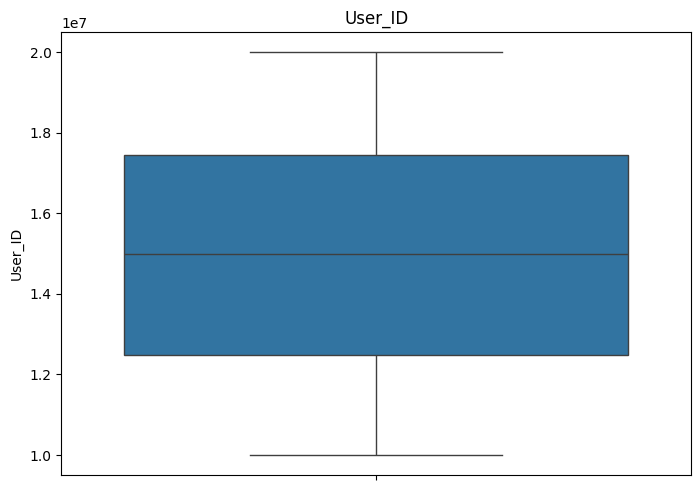

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Select numeric columns except target
# ==============================
target_col = 'Calories'
numeric_cols = df.select_dtypes(include='number').columns

attributes = [col for col in numeric_cols if col != target_col]

# ==============================
# Create subplots (auto layout)
# ==============================
n = len(attributes)
rows = (n // 3) + (n % 3 > 0)

fig, axes = plt.subplots(rows, 3, figsize=(20, 5 * rows))
axes = axes.flatten()

# ==============================
# Plot boxplots
# ==============================
for i, col in enumerate(attributes):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Shape: (15000, 2)

Columns: Index(['User_ID', 'Calories'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB

Missing Values:
User_ID     0
Calories    0
dtype: int64

Statistical Summary:
            User_ID      Calories
count  1.500000e+04  15000.000000
mean   1.497736e+07     89.539533
std    2.872851e+06     62.456978
min    1.000116e+07      1.000000
25%    1.247419e+07     35.000000
50%    1.499728e+07     79.000000
75%    1.744928e+07    138.000000
max    1.999965e+07    314.000000


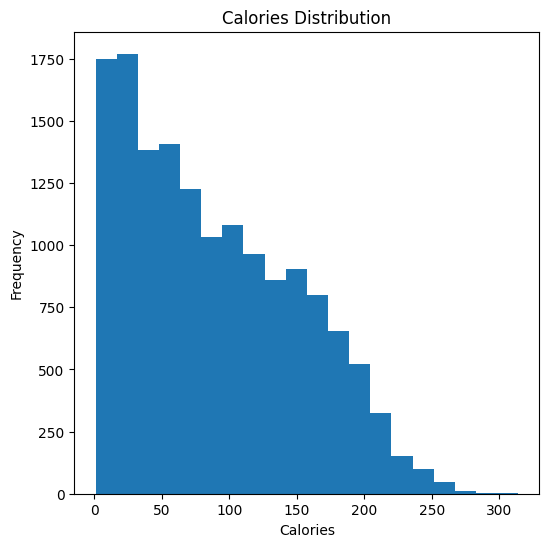

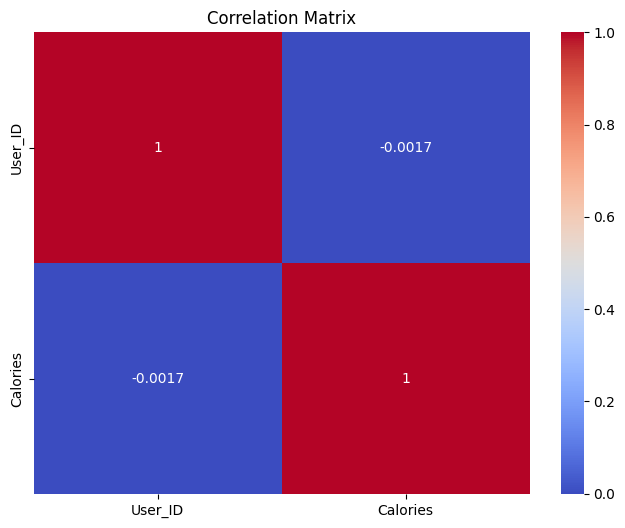

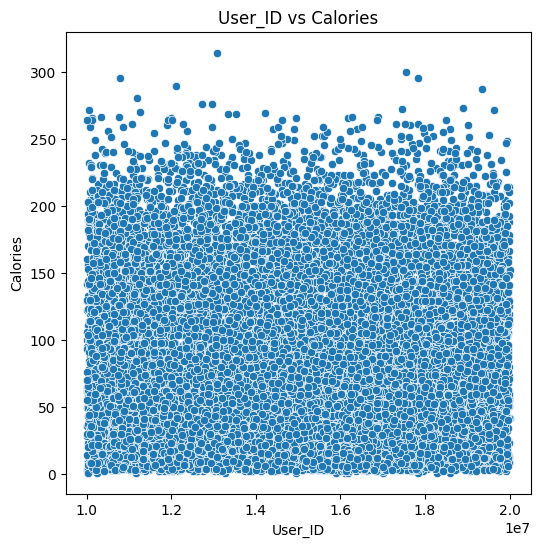

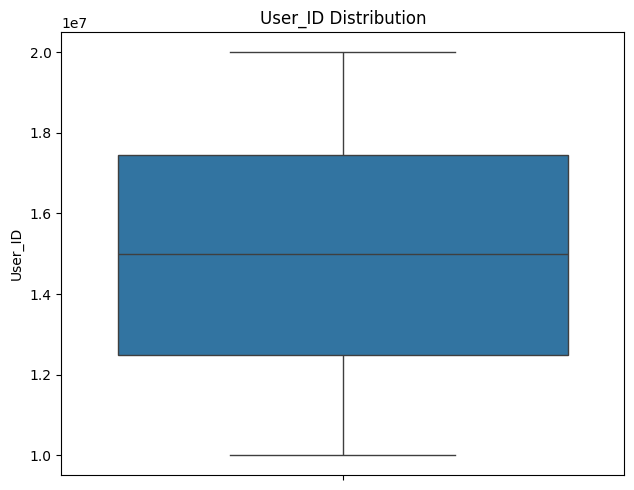

Linear Regression -> R2: -0.001, MAE: 53.93
Random Forest -> R2: -0.499, MAE: 63.05
SVR -> R2: -0.047, MAE: 53.88
XGBoost -> R2: -0.013, MAE: 54.22


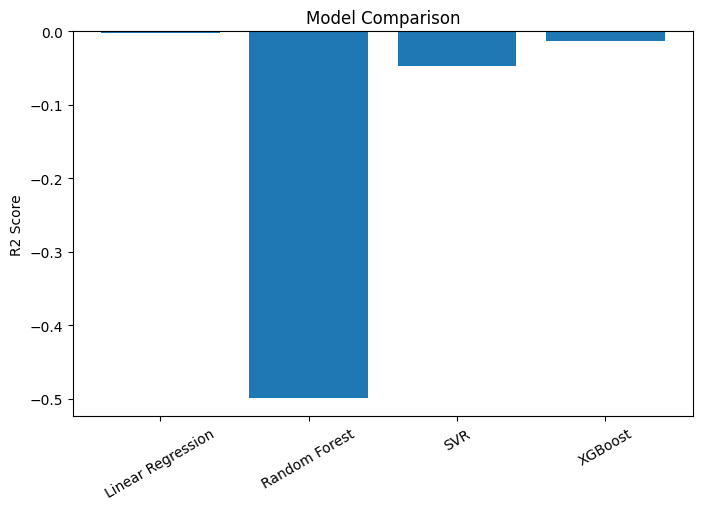


Final Results:
{'Linear Regression': {'R2': -0.0014323927992658803, 'MAE': 53.93364822763257}, 'Random Forest': {'R2': -0.49928420201873935, 'MAE': 63.04677157936508}, 'SVR': {'R2': -0.04662535270308976, 'MAE': 53.879330929908726}, 'XGBoost': {'R2': -0.013115775734295676, 'MAE': 54.222828344980876}}


In [22]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# ==============================
# 3. Basic EDA
# ==============================
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nInfo:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ==============================
# 4. Visualization
# ==============================

# Histogram
plt.figure(figsize=(6,6))
plt.hist(df['Calories'], bins=20)
plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Best Feature Scatter Plot
corr = df.corr(numeric_only=True)['Calories'].sort_values(ascending=False)
best_feature = corr.index[1]

plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x=best_feature, y='Calories')
plt.title(f"{best_feature} vs Calories")
plt.show()

# ==============================
# 5. Boxplots (All Features)
# ==============================
target_col = 'Calories'
numeric_cols = df.select_dtypes(include='number').columns
features = [col for col in numeric_cols if col != target_col]

cols = 3
rows = (len(features) // cols) + (len(features) % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ==============================
# 6. Features & Target
# ==============================
X = df.drop(target_col, axis=1)
y = df[target_col]

# ==============================
# 7. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 8. Scaling
# ==============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 9. Models
# ==============================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5)
}

# ==============================
# 10. Train & Evaluate
# ==============================
results = {}

for name, model in models.items():
    
    if name in ["Linear Regression", "SVR"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {"R2": r2, "MAE": mae}
    
    print(f"{name} -> R2: {r2:.3f}, MAE: {mae:.2f}")

# ==============================
# 11. Model Comparison Plot
# ==============================
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [v['R2'] for v in results.values()])
plt.xticks(rotation=30)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

print("\nFinal Results:")
print(results)

Shape: (15000, 2)

Columns: Index(['User_ID', 'Calories'], dtype='object')

Missing Values:
 User_ID     0
Calories    0
dtype: int64
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best XGBoost Params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best RF Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}

XGBoost
R2: -0.003
MAE: 54.00

Random Forest
R2: -0.010
MAE: 54.15


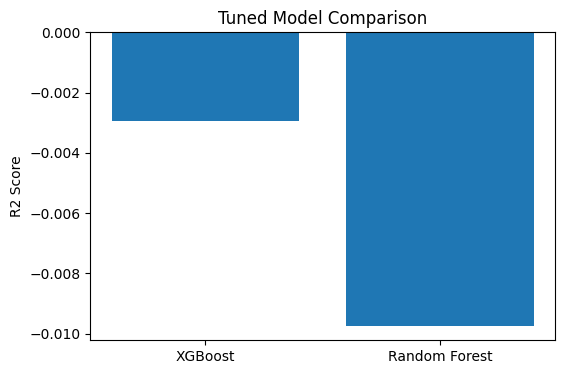

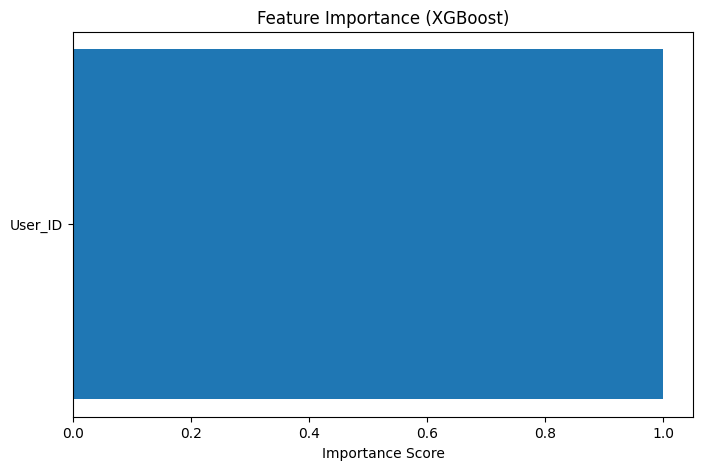

In [23]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# Clean column names
df.columns = df.columns.str.strip()

# ==============================
# 3. Basic EDA
# ==============================
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

# ==============================
# 4. Target & Features
# ==============================
target_col = 'Calories'   # change if needed

X = df.drop(target_col, axis=1)
y = df[target_col]

# ==============================
# 5. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 6. Hyperparameter Tuning - XGBoost
# ==============================
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

xgb = XGBRegressor(random_state=42)

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_random.fit(X_train, y_train)

print("\nBest XGBoost Params:", xgb_random.best_params_)

best_xgb = xgb_random.best_estimator_

# ==============================
# 7. Hyperparameter Tuning - Random Forest
# ==============================
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_random.fit(X_train, y_train)

print("\nBest RF Params:", rf_random.best_params_)

best_rf = rf_random.best_estimator_

# ==============================
# 8. Evaluate Models
# ==============================
results = {}

# XGBoost
y_pred_xgb = best_xgb.predict(X_test)
results['XGBoost'] = {
    "R2": r2_score(y_test, y_pred_xgb),
    "MAE": mean_absolute_error(y_test, y_pred_xgb)
}

# Random Forest
y_pred_rf = best_rf.predict(X_test)
results['Random Forest'] = {
    "R2": r2_score(y_test, y_pred_rf),
    "MAE": mean_absolute_error(y_test, y_pred_rf)
}

# Print results
for model, metrics in results.items():
    print(f"\n{model}")
    print(f"R2: {metrics['R2']:.3f}")
    print(f"MAE: {metrics['MAE']:.2f}")

# ==============================
# 9. Plot Comparison
# ==============================
plt.figure(figsize=(6,4))
plt.bar(results.keys(), [v['R2'] for v in results.values()])
plt.ylabel("R2 Score")
plt.title("Tuned Model Comparison")
plt.show()

# ==============================
# 10. Feature Importance (XGBoost)
# ==============================
importance = best_xgb.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(X.columns, importance)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

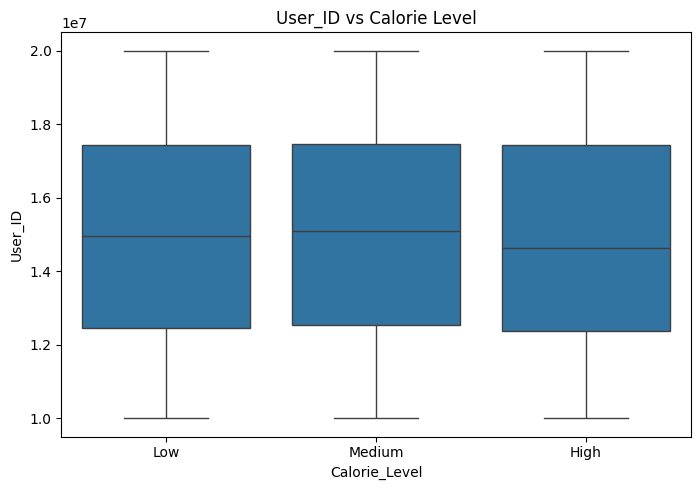

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Define target
# ==============================
target_col = 'Calories'

# ==============================
# Create categories from Calories
# ==============================
df['Calorie_Level'] = pd.cut(df['Calories'], bins=3, labels=['Low', 'Medium', 'High'])

# ==============================
# Get numeric features
# ==============================
numeric_cols = df.select_dtypes(include='number').columns
features = [col for col in numeric_cols if col != target_col]

# ==============================
# Create subplot grid
# ==============================
cols = 3
rows = (len(features) // cols) + (len(features) % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

# ==============================
# Plot boxplots
# ==============================
for i, col in enumerate(features):
    sns.boxplot(x='Calorie_Level', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Calorie Level")

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

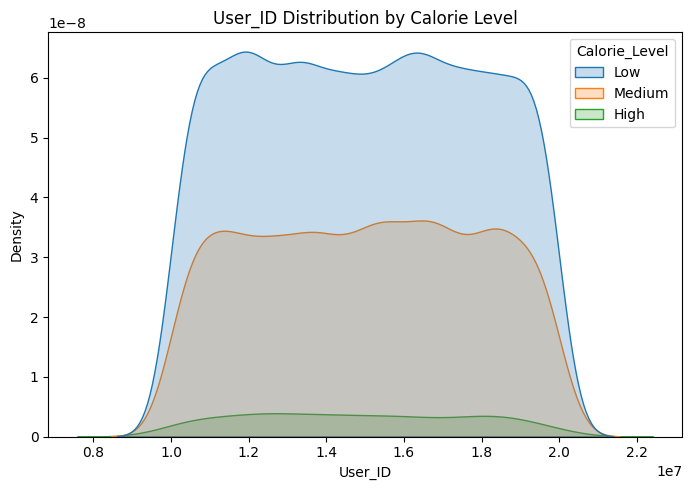

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================
# Create target categories
# ==============================
df['Calorie_Level'] = pd.cut(df['Calories'], bins=3, labels=['Low', 'Medium', 'High'])

# ==============================
# Select numeric features
# ==============================
target_col = 'Calories'
numeric_cols = df.select_dtypes(include='number').columns
features = [col for col in numeric_cols if col != target_col]

# ==============================
# Create subplot grid
# ==============================
cols = 3
rows = (len(features) // cols) + (len(features) % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

# ==============================
# KDE Plots
# ==============================
for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='Calorie_Level', fill=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution by Calorie Level")

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Shape: (15000, 2)

Columns: Index(['User_ID', 'Calories'], dtype='object')

Missing Values:
 User_ID     0
Calories    0
dtype: int64


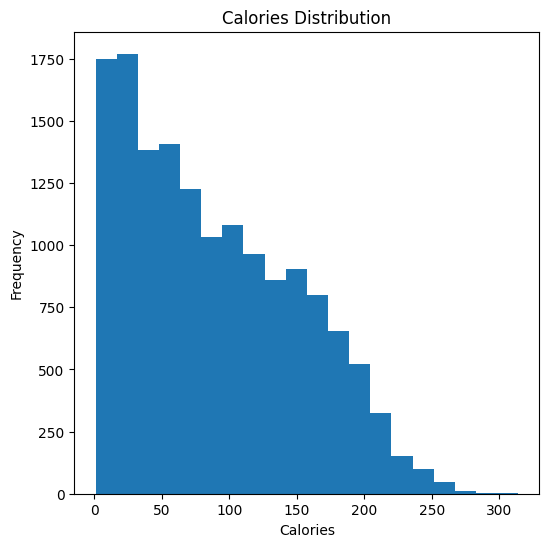

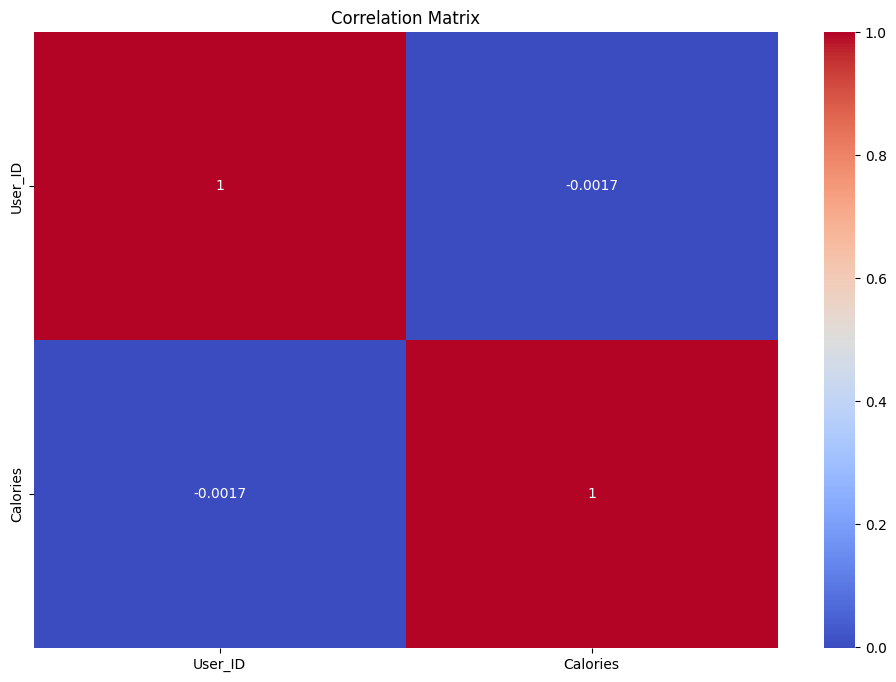

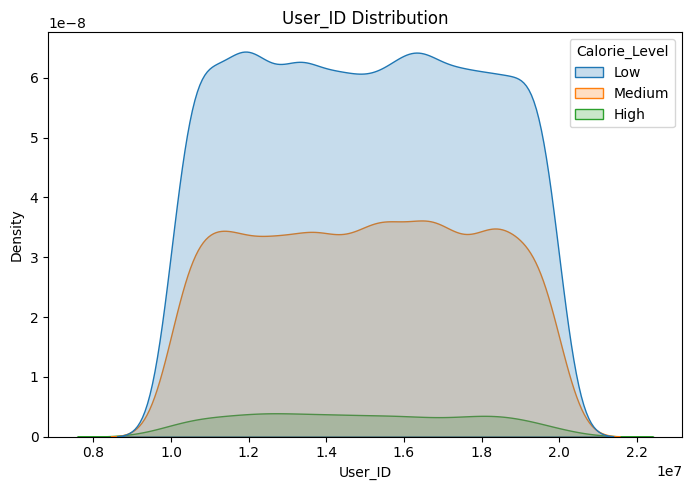

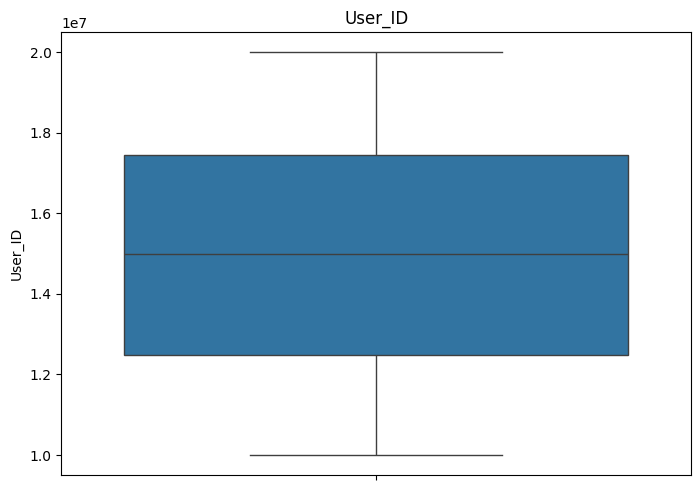

Fitting 3 folds for each of 10 candidates, totalling 30 fits


ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\KIIT\miniconda3\Lib\site-packages\xgboost\data.py", line 408, in pandas_feature_info
    new_feature_types.append(_pandas_dtype_mapper[dtype.name])
                             ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'category'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\KIIT\miniconda3\Lib\site-packages\xgboost\core.py", line 

In [26]:
#All the attributes follow almost the same distribution (with differing heights) and their average lies near the same data points irrespective of the potability.
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# Clean column names
df.columns = df.columns.str.strip()

# ==============================
# 3. Basic EDA
# ==============================
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

# ==============================
# 4. Visualization
# ==============================

# Histogram
plt.figure(figsize=(6,6))
plt.hist(df['Calories'], bins=20)
plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

# Heatmap (FIXED)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 5. KDE Plots (Feature vs Target)
# ==============================
df['Calorie_Level'] = pd.cut(df['Calories'], bins=3, labels=['Low', 'Medium', 'High'])

numeric_cols = df.select_dtypes(include='number').columns
features = [col for col in numeric_cols if col != 'Calories']

cols = 3
rows = (len(features) // cols) + (len(features) % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='Calorie_Level', fill=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ==============================
# 6. Boxplots
# ==============================
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ==============================
# 7. Features & Target
# ==============================
X = df.drop('Calories', axis=1)
y = df['Calories']

# ==============================
# 8. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 9. Hyperparameter Tuning - XGBoost
# ==============================
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

xgb = XGBRegressor(random_state=42)

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("Best XGB Params:", xgb_search.best_params_)

# ==============================
# 10. Hyperparameter Tuning - RF
# ==============================
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best RF Params:", rf_search.best_params_)

# ==============================
# 11. Evaluation
# ==============================
results = {}

# XGBoost
y_pred_xgb = best_xgb.predict(X_test)
results['XGBoost'] = {
    "R2": r2_score(y_test, y_pred_xgb),
    "MAE": mean_absolute_error(y_test, y_pred_xgb)
}

# Random Forest
y_pred_rf = best_rf.predict(X_test)
results['Random Forest'] = {
    "R2": r2_score(y_test, y_pred_rf),
    "MAE": mean_absolute_error(y_test, y_pred_rf)
}

# Print results
for model, metrics in results.items():
    print(f"\n{model}")
    print(f"R2: {metrics['R2']:.3f}")
    print(f"MAE: {metrics['MAE']:.2f}")

# ==============================
# 12. Comparison Plot
# ==============================
plt.figure(figsize=(6,4))
plt.bar(results.keys(), [v['R2'] for v in results.values()])
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

# ==============================
# 13. Feature Importance
# ==============================
importance = best_xgb.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(X.columns, importance)
plt.title("Feature Importance (XGBoost)")
plt.show()

Shape: (15000, 2)

Columns:
 Index(['User_ID', 'Calories'], dtype='object')

Missing Values:
 User_ID     0
Calories    0
dtype: int64

Summary:
             User_ID      Calories
count  1.500000e+04  15000.000000
mean   1.497736e+07     89.539533
std    2.872851e+06     62.456978
min    1.000116e+07      1.000000
25%    1.247419e+07     35.000000
50%    1.499728e+07     79.000000
75%    1.744928e+07    138.000000
max    1.999965e+07    314.000000


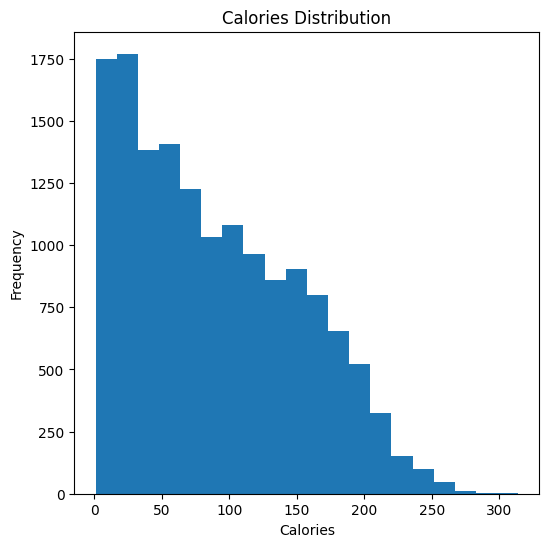

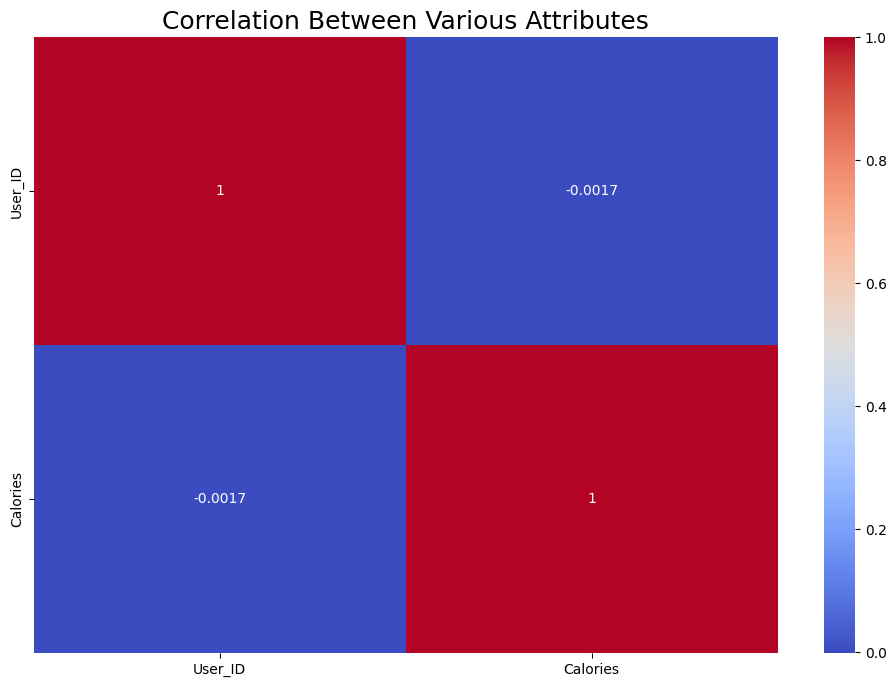

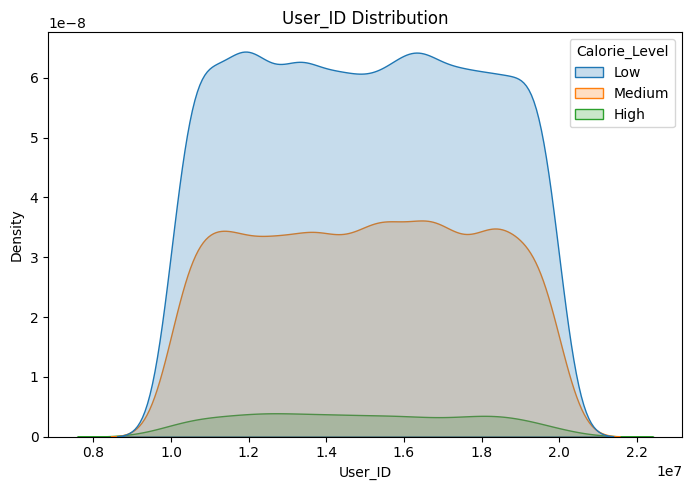

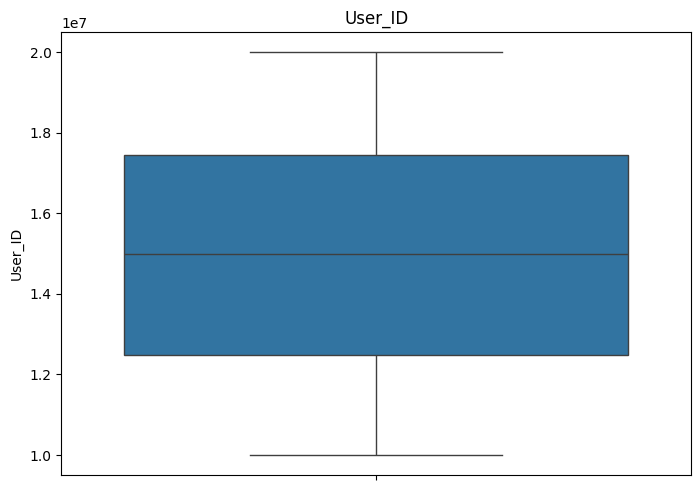

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGB Params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}

XGBoost
R2: -0.004
MAE: 54.02

Random Forest
R2: -0.010
MAE: 54.15


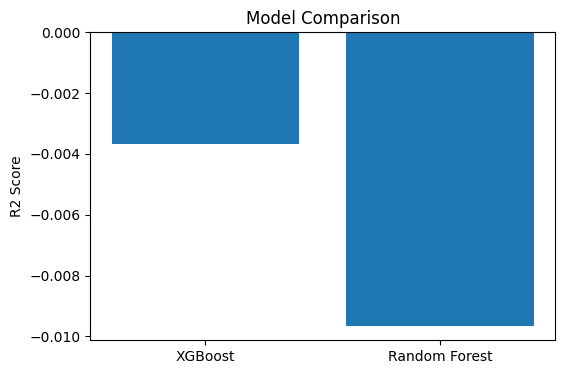

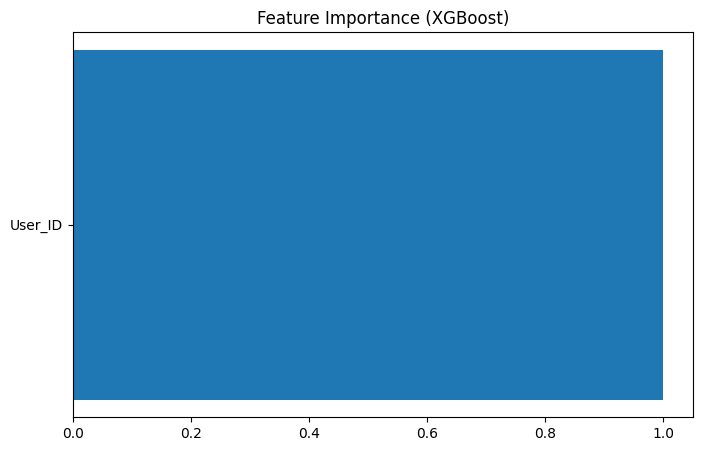

In [27]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# Clean column names
df.columns = df.columns.str.strip()

# ==============================
# 3. Basic EDA
# ==============================
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary:\n", df.describe())

# ==============================
# 4. Visualization
# ==============================

# Histogram
plt.figure(figsize=(6,6))
plt.hist(df['Calories'], bins=20)
plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

# Heatmap (FIXED)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Between Various Attributes', fontsize=18)
plt.show()

# ==============================
# 5. KDE + Boxplots
# ==============================
# Create categories for visualization
df['Calorie_Level'] = pd.cut(df['Calories'], bins=3, labels=['Low','Medium','High'])

numeric_cols = df.select_dtypes(include='number').columns
features = [col for col in numeric_cols if col != 'Calories']

# KDE plots
cols = 3
rows = (len(features)//cols) + (len(features)%cols>0)

fig, axes = plt.subplots(rows, cols, figsize=(20,5*rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='Calorie_Level', fill=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Boxplots
fig, axes = plt.subplots(rows, cols, figsize=(20,5*rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ==============================
# 6. Features & Target
# ==============================
X = df.drop(['Calories','Calorie_Level'], axis=1)
y = df['Calories']

# ==============================
# 7. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 8. Hyperparameter Tuning (XGBoost)
# ==============================
xgb_params = {
    'n_estimators': [100,200,300],
    'max_depth': [3,5,7],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.7,1.0],
    'colsample_bytree': [0.7,1.0]
}

xgb = XGBRegressor(random_state=42)

xgb_search = RandomizedSearchCV(
    xgb, xgb_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("Best XGB Params:", xgb_search.best_params_)

# ==============================
# 9. Hyperparameter Tuning (RF)
# ==============================
rf_params = {
    'n_estimators': [100,200],
    'max_depth': [None,10,20],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]
}

rf = RandomForestRegressor(random_state=42)

rf_search = RandomizedSearchCV(
    rf, rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best RF Params:", rf_search.best_params_)

# ==============================
# 10. Evaluation
# ==============================
results = {}

# XGB
y_pred_xgb = best_xgb.predict(X_test)
results['XGBoost'] = {
    "R2": r2_score(y_test, y_pred_xgb),
    "MAE": mean_absolute_error(y_test, y_pred_xgb)
}

# RF
y_pred_rf = best_rf.predict(X_test)
results['Random Forest'] = {
    "R2": r2_score(y_test, y_pred_rf),
    "MAE": mean_absolute_error(y_test, y_pred_rf)
}

# Print results
for model, metrics in results.items():
    print(f"\n{model}")
    print(f"R2: {metrics['R2']:.3f}")
    print(f"MAE: {metrics['MAE']:.2f}")

# ==============================
# 11. Comparison Plot
# ==============================
plt.figure(figsize=(6,4))
plt.bar(results.keys(), [v['R2'] for v in results.values()])
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

# ==============================
# 12. Feature Importance (XGB)
# ==============================
importance = best_xgb.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(X.columns, importance)
plt.title("Feature Importance (XGBoost)")
plt.show()

In [28]:
#Missing Values
#Getting the missing values : We will find out all the missing values from the dataset using insa().
#Missing values from the train data
train_df.isna().sum()

User_ID     0
Calories    0
dtype: int64

Shape: (15000, 2)

Columns:
 Index(['User_ID', 'Calories'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB

Missing Values:
User_ID     0
Calories    0
dtype: int64

Statistical Summary:
            User_ID      Calories
count  1.500000e+04  15000.000000
mean   1.497736e+07     89.539533
std    2.872851e+06     62.456978
min    1.000116e+07      1.000000
25%    1.247419e+07     35.000000
50%    1.499728e+07     79.000000
75%    1.744928e+07    138.000000
max    1.999965e+07    314.000000


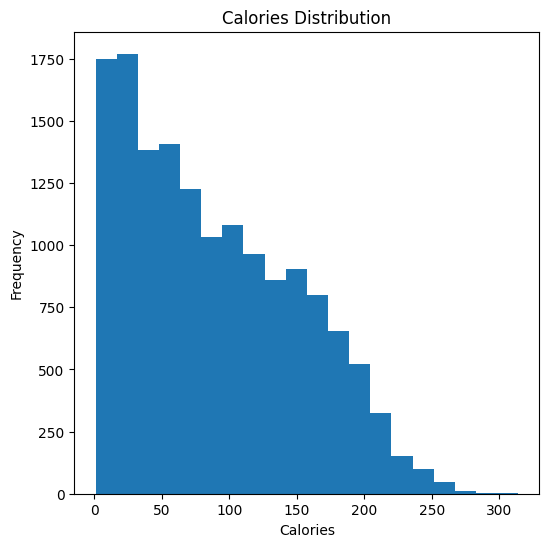

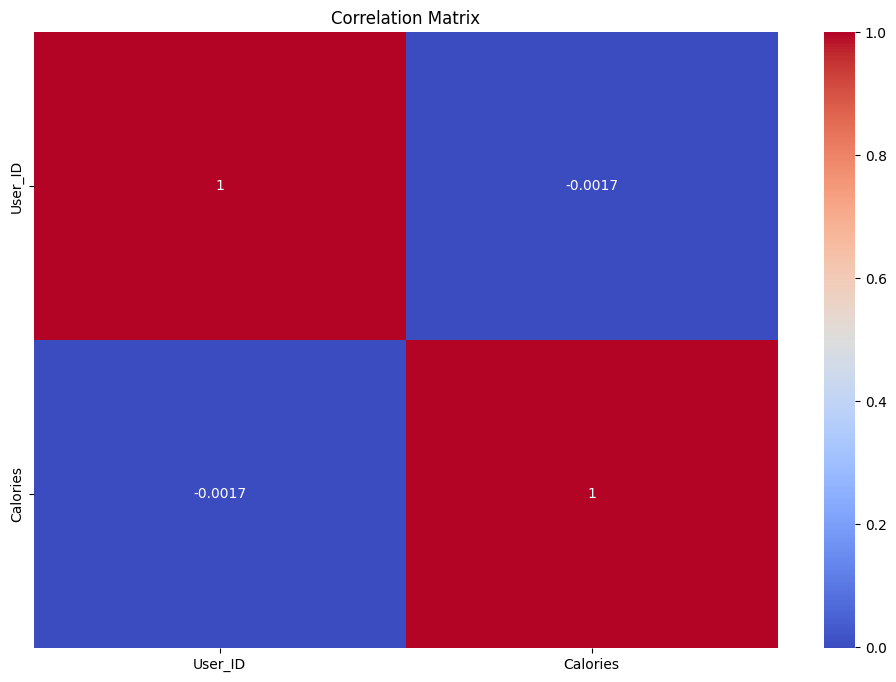

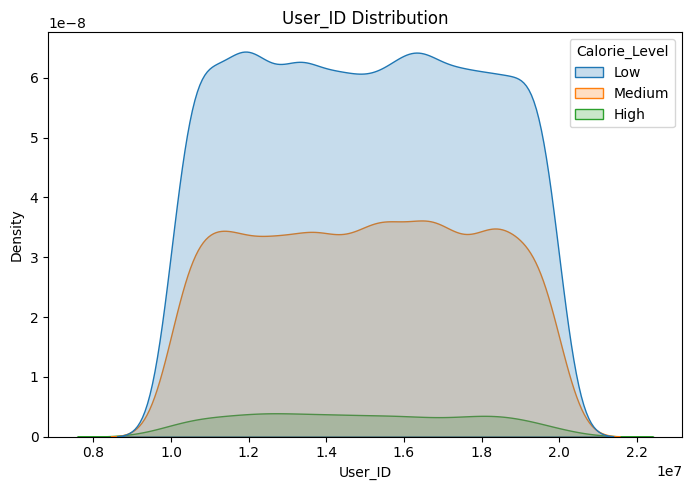

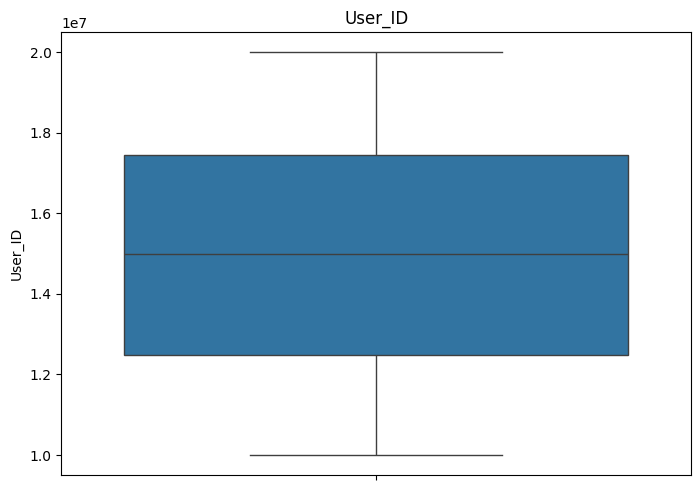

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best XGB Params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best RF Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}

XGBoost
R2: -0.004
MAE: 54.02

Random Forest
R2: -0.010
MAE: 54.15


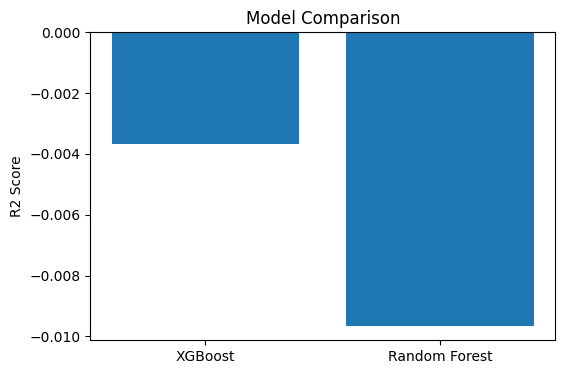

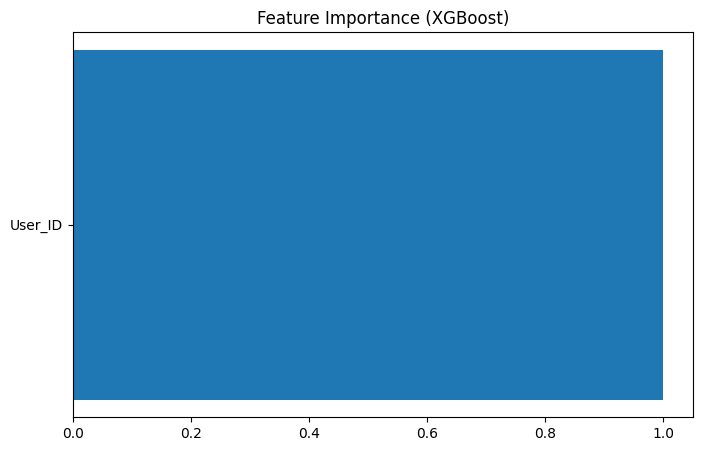

In [29]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# Clean column names
df.columns = df.columns.str.strip()

# ==============================
# 3. Basic EDA
# ==============================
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:")
df.info()

print("\nMissing Values:")
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

print("\nStatistical Summary:")
print(df.describe())

# ==============================
# 4. Handle Missing Values
# ==============================
# Fill numeric columns with median
df.fillna(df.median(numeric_only=True), inplace=True)

# ==============================
# 5. Visualization
# ==============================

# Histogram
plt.figure(figsize=(6,6))
plt.hist(df['Calories'], bins=20)
plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 6. KDE & Boxplots
# ==============================
df['Calorie_Level'] = pd.cut(df['Calories'], bins=3, labels=['Low','Medium','High'])

numeric_cols = df.select_dtypes(include='number').columns
features = [col for col in numeric_cols if col != 'Calories']

# KDE plots
cols = 3
rows = (len(features)//cols) + (len(features)%cols>0)

fig, axes = plt.subplots(rows, cols, figsize=(20,5*rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='Calorie_Level', fill=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Boxplots
fig, axes = plt.subplots(rows, cols, figsize=(20,5*rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ==============================
# 7. Features & Target
# ==============================
X = df.drop(['Calories','Calorie_Level'], axis=1)
y = df['Calories']

# ==============================
# 8. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 9. Hyperparameter Tuning - XGBoost
# ==============================
xgb_params = {
    'n_estimators': [100,200,300],
    'max_depth': [3,5,7],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.7,1.0],
    'colsample_bytree': [0.7,1.0]
}

xgb = XGBRegressor(random_state=42)

xgb_search = RandomizedSearchCV(
    xgb, xgb_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("\nBest XGB Params:", xgb_search.best_params_)

# ==============================
# 10. Hyperparameter Tuning - RF
# ==============================
rf_params = {
    'n_estimators': [100,200],
    'max_depth': [None,10,20],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]
}

rf = RandomForestRegressor(random_state=42)

rf_search = RandomizedSearchCV(
    rf, rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("\nBest RF Params:", rf_search.best_params_)

# ==============================
# 11. Evaluation
# ==============================
results = {}

# XGBoost
y_pred_xgb = best_xgb.predict(X_test)
results['XGBoost'] = {
    "R2": r2_score(y_test, y_pred_xgb),
    "MAE": mean_absolute_error(y_test, y_pred_xgb)
}

# Random Forest
y_pred_rf = best_rf.predict(X_test)
results['Random Forest'] = {
    "R2": r2_score(y_test, y_pred_rf),
    "MAE": mean_absolute_error(y_test, y_pred_rf)
}

# Print results
for model, metrics in results.items():
    print(f"\n{model}")
    print(f"R2: {metrics['R2']:.3f}")
    print(f"MAE: {metrics['MAE']:.2f}")

# ==============================
# 12. Comparison Plot
# ==============================
plt.figure(figsize=(6,4))
plt.bar(results.keys(), [v['R2'] for v in results.values()])
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

# ==============================
# 13. Feature Importance
# ==============================
importance = best_xgb.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(X.columns, importance)
plt.title("Feature Importance (XGBoost)")
plt.show()

In [30]:
#Missing values from the train data
train_df.isna().sum()

User_ID     0
Calories    0
dtype: int64

In [32]:
train_df.to_csv('water_potability_preprocessed.csv', index=False)

In [33]:
#Scaling
#We will scale down all the data points in the range of 0 to 1, so that our algorithm doesn't have to deal with variety of wide ranges.
#Min-Max range before scaling
train_df.describe().T[['min','max']].T

,User_ID,Calories
min,10001159.0,1.0
max,19999647.0,314.0


In [34]:
input_cols = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity']

Accuracy: 0.6326219512195121

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.74      0.71       400
           1       0.53      0.46      0.49       256

    accuracy                           0.63       656
   macro avg       0.61      0.60      0.60       656
weighted avg       0.62      0.63      0.63       656


Confusion Matrix:
 [[297 103]
 [138 118]]


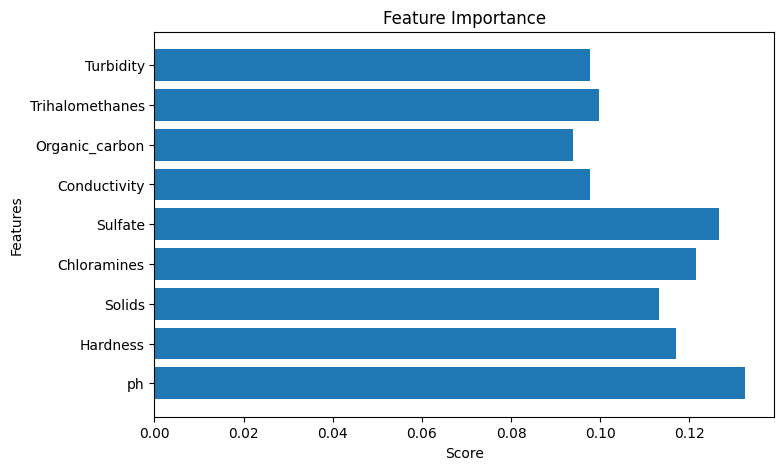


Sample Predictions: [0 0 0 0 0 0 0 0 0 0]


In [38]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\water_potability.csv")

# =========================
# 3. Handle Missing Values (FIXED)
# =========================
df = df.fillna(df.median(numeric_only=True))

# =========================
# 4. Split Features & Target
# =========================
target_col = "Potability"
X = df.drop(columns=[target_col])
y = df[target_col]

# =========================
# 5. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 6. Feature Scaling
# =========================
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 7. Handle Class Imbalance
# =========================
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# =========================
# 8. Model (UPDATED - NO deprecated params)
# =========================
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

# =========================
# 9. Train Model
# =========================
model.fit(X_train, y_train)

# =========================
# 10. Predictions
# =========================
y_pred = model.predict(X_test)

# =========================
# 11. Evaluation
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================
# 12. Feature Importance
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.xlabel("Score")
plt.ylabel("Features")
plt.show()

# =========================
# 13. Sample Predictions
# =========================
print("\nSample Predictions:", y_pred[:10])

In [39]:
#Scaling
#We will scale down all the data points in the range of 0 to 1, so that our algorithm doesn't have to deal with variety of wide ranges.
#Min-Max range before scaling
train_df.describe().T[['min','max']].T

,User_ID,Calories
min,10001159.0,1.0
max,19999647.0,314.0


In [40]:
input_cols = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity']

In [42]:
from sklearn.preprocessing import MinMaxScaler

# =========================
# 1. Clean column names (IMPORTANT FIX)
# =========================
train_df.columns = train_df.columns.str.strip()

# =========================
# 2. Define target column
# =========================
target_col = "Potability"

# =========================
# 3. Automatically select input columns
# =========================
input_cols = [col for col in train_df.columns if col != target_col]

# =========================
# 4. Scaling
# =========================
scaler = MinMaxScaler()

train_df[input_cols] = scaler.fit_transform(train_df[input_cols])

# =========================
# 5. Check result
# =========================
train_df.head()

,User_ID,Calories
0,0.473292,0.734824
1,0.486127,0.207668
2,0.117888,0.079872
3,0.618018,0.223642
4,0.777194,0.108626


In [43]:
scaler = MinMaxScaler()
scaler.fit(train_df[input_cols])
train_df[input_cols] = scaler.transform(train_df[input_cols])
train_df.head()

,User_ID,Calories
0,0.473292,0.734824
1,0.486127,0.207668
2,0.117888,0.079872
3,0.618018,0.223642
4,0.777194,0.108626


In [44]:
#Min-Max range after scaling
train_df.describe().T[['min','max']].T

,User_ID,Calories
min,0.0,0.0
max,1.0,1.0


Columns in dataset: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']
Target column detected: Potability

Accuracy: 0.6326219512195121

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.74      0.71       400
           1       0.53      0.46      0.49       256

    accuracy                           0.63       656
   macro avg       0.61      0.60      0.60       656
weighted avg       0.62      0.63      0.63       656


Confusion Matrix:

[[297 103]
 [138 118]]


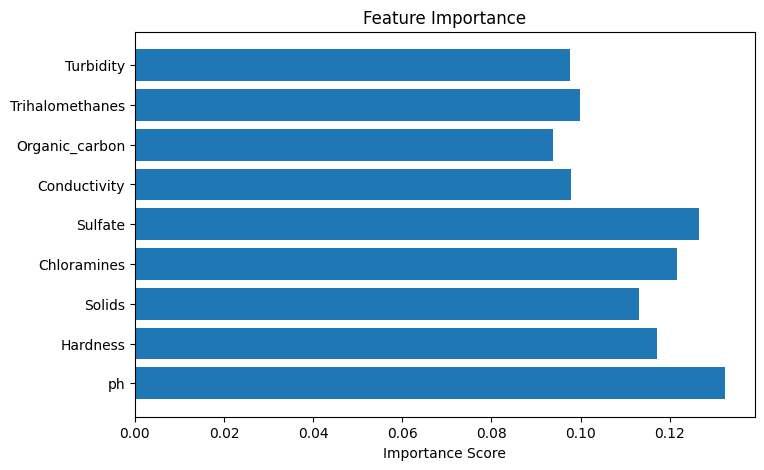


Sample Predictions: [0 0 0 0 0 0 0 0 0 0]


In [47]:
#Modeling
#Seperating Response Variable from the dataset
# Clean column names
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

# =========================
# 2. Load Dataset
# =========================
train_df = pd.read_csv(r"C:\Users\KIIT\Downloads\water_potability.csv")

# =========================
# 3. Clean Column Names
# =========================
train_df.columns = train_df.columns.str.strip()

print("Columns in dataset:", train_df.columns.tolist())

# =========================
# 4. Auto-detect target column safely
# =========================
possible_targets = [col for col in train_df.columns if col.lower() == "potability"]

if len(possible_targets) == 0:
    raise ValueError("❌ 'Potability' column not found in dataset")

target_col = possible_targets[0]

print("Target column detected:", target_col)

# =========================
# 5. Handle Missing Values
# =========================
train_df = train_df.fillna(train_df.median(numeric_only=True))

# =========================
# 6. Split Features & Target
# =========================
X = train_df.drop(columns=[target_col])
y = train_df[target_col]

# =========================
# 7. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 8. Feature Scaling
# =========================
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 9. Handle Class Imbalance
# =========================
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# =========================
# 10. Model Training
# =========================
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# =========================
# 11. Prediction
# =========================
y_pred = model.predict(X_test)

# =========================
# 12. Evaluation
# =========================
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# =========================
# 13. Feature Importance
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

# =========================
# 14. Sample Predictions
# =========================
print("\nSample Predictions:", y_pred[:10])

In [48]:
X.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity'],
      dtype='object')

In [49]:
#train_test_split()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# =========================
# Model
# =========================
clf = DecisionTreeClassifier(
    random_state=41,
    max_depth=6,
    min_samples_split=2   # FIXED (should be integer, not 0.03)
)

# =========================
# Train Model
# =========================
clf.fit(X_train, y_train)

# =========================
# Predictions
# =========================
y_pred_test = clf.predict(X_test)
y_pred_train = clf.predict(X_train)

# =========================
# Accuracy
# =========================
print("Accuracy of training data :", accuracy_score(y_train, y_pred_train))
print("Accuracy of validation data :", accuracy_score(y_test, y_pred_test))

Accuracy of training data : 0.6967846967846968
Accuracy of validation data : 0.6056166056166056


Training Accuracy: 0.6923664122137405
Testing Accuracy: 0.6463414634146342

Confusion Matrix:
 [[358  42]
 [190  66]]


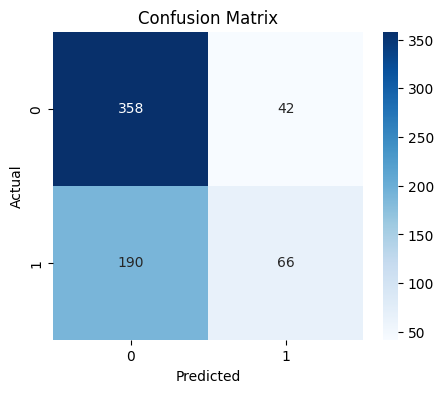


Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.90      0.76       400
           1       0.61      0.26      0.36       256

    accuracy                           0.65       656
   macro avg       0.63      0.58      0.56       656
weighted avg       0.64      0.65      0.60       656



In [53]:
#Confusion Matrix
#We had earlier seen that the large portion of water samples is not potable, that means our dataset is imbalanced and we need confusion matrix to evaluate our model.
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 2. Load Dataset
# =========================
train_df = pd.read_csv(r"C:\Users\KIIT\Downloads\water_potability.csv")

# =========================
# 3. Clean Column Names
# =========================
train_df.columns = train_df.columns.str.strip()

# =========================
# 4. Handle Missing Values
# =========================
train_df = train_df.fillna(train_df.median(numeric_only=True))

# =========================
# 5. Split Features & Target
# =========================
target_col = "Potability"

X = train_df.drop(columns=[target_col])
y = train_df[target_col]

# =========================
# 6. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 7. Feature Scaling
# =========================
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 8. Train Decision Tree Model
# =========================
clf = DecisionTreeClassifier(
    random_state=41,
    max_depth=6,
    min_samples_split=2
)

clf.fit(X_train, y_train)

# =========================
# 9. Predictions
# =========================
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

# =========================
# 10. Accuracy
# =========================
print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test))

# =========================
# 11. Confusion Matrix
# =========================
cf_matrix = confusion_matrix(y_test, y_pred_test)

print("\nConfusion Matrix:\n", cf_matrix)

# =========================
# 12. Confusion Matrix Heatmap
# =========================
plt.figure(figsize=(5,4))
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 13. Classification Report
# =========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_test))


Training Accuracy: 0.6923664122137405
Testing Accuracy: 0.6463414634146342

Confusion Matrix:
 [[358  42]
 [190  66]]


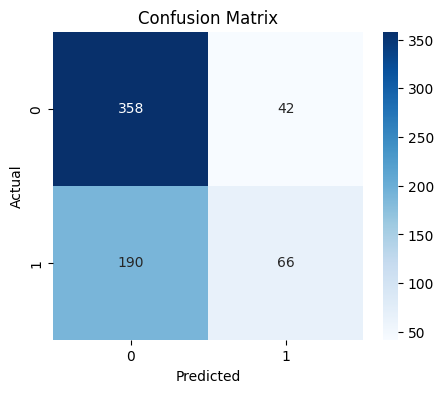


Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.90      0.76       400
           1       0.61      0.26      0.36       256

    accuracy                           0.65       656
   macro avg       0.63      0.58      0.56       656
weighted avg       0.64      0.65      0.60       656



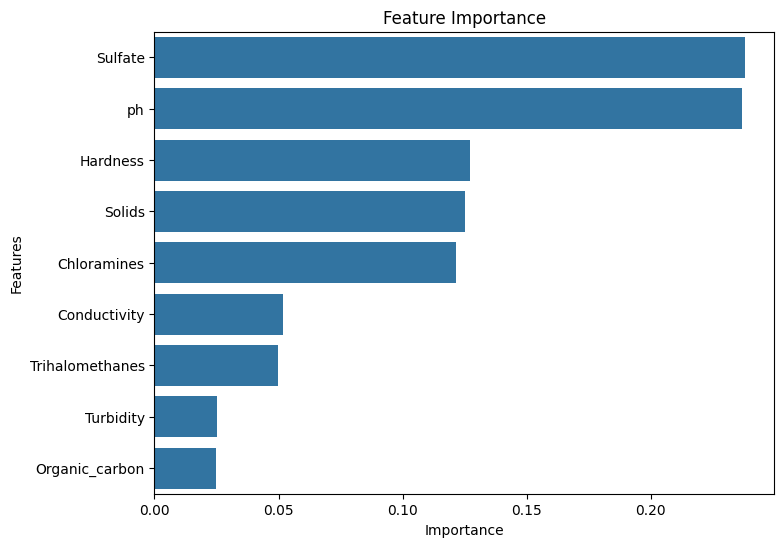

In [54]:
#Feature Importance
#It highlights which features passed into a model have a higher degree of impact for generating a prediction than others.
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# =========================
# 2. Load Dataset
# =========================
train_df = pd.read_csv(r"C:\Users\KIIT\Downloads\water_potability.csv")

# =========================
# 3. Clean Column Names
# =========================
train_df.columns = train_df.columns.str.strip()

# =========================
# 4. Handle Missing Values
# =========================
train_df = train_df.fillna(train_df.median(numeric_only=True))

# =========================
# 5. Split Features & Target
# =========================
target_col = "Potability"

X = train_df.drop(columns=[target_col])
y = train_df[target_col]

# SAVE FEATURE NAMES (IMPORTANT FOR LATER)
feature_names = X.columns

# =========================
# 6. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 7. Feature Scaling
# =========================
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 8. Train Decision Tree Model
# =========================
clf = DecisionTreeClassifier(
    random_state=41,
    max_depth=6,
    min_samples_split=2
)

clf.fit(X_train, y_train)

# =========================
# 9. Predictions
# =========================
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

# =========================
# 10. Accuracy
# =========================
print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test))

# =========================
# 11. Confusion Matrix
# =========================
cf_matrix = confusion_matrix(y_test, y_pred_test)

print("\nConfusion Matrix:\n", cf_matrix)

plt.figure(figsize=(5,4))
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 12. Classification Report
# =========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_test))

# =========================
# 13. Feature Importance (FIXED)
# =========================
feature_importance = pd.DataFrame({
    'Features': feature_names,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    x=feature_importance['Importance'],
    y=feature_importance['Features']
)

plt.title("Feature Importance")
plt.show()

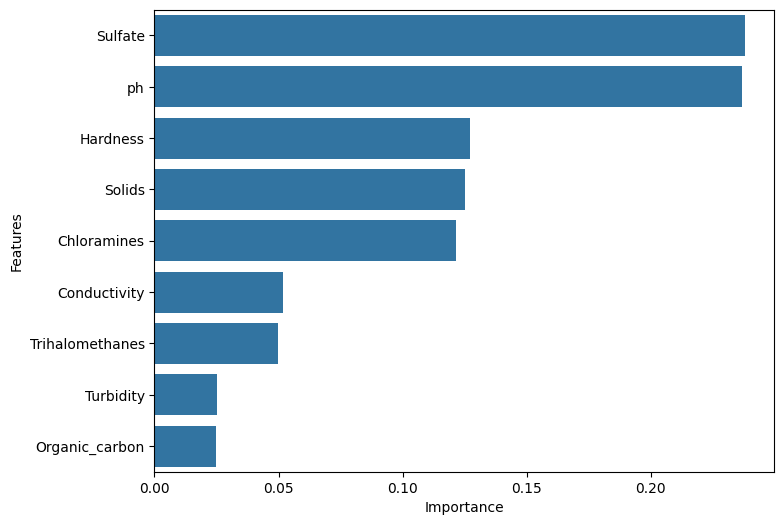

In [55]:
feature_importance = pd.DataFrame({'Features':X.columns,
                                   'Importance':clf.feature_importances_
                                  }).sort_values('Importance', ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=feature_importance['Importance'], y=feature_importance['Features']);

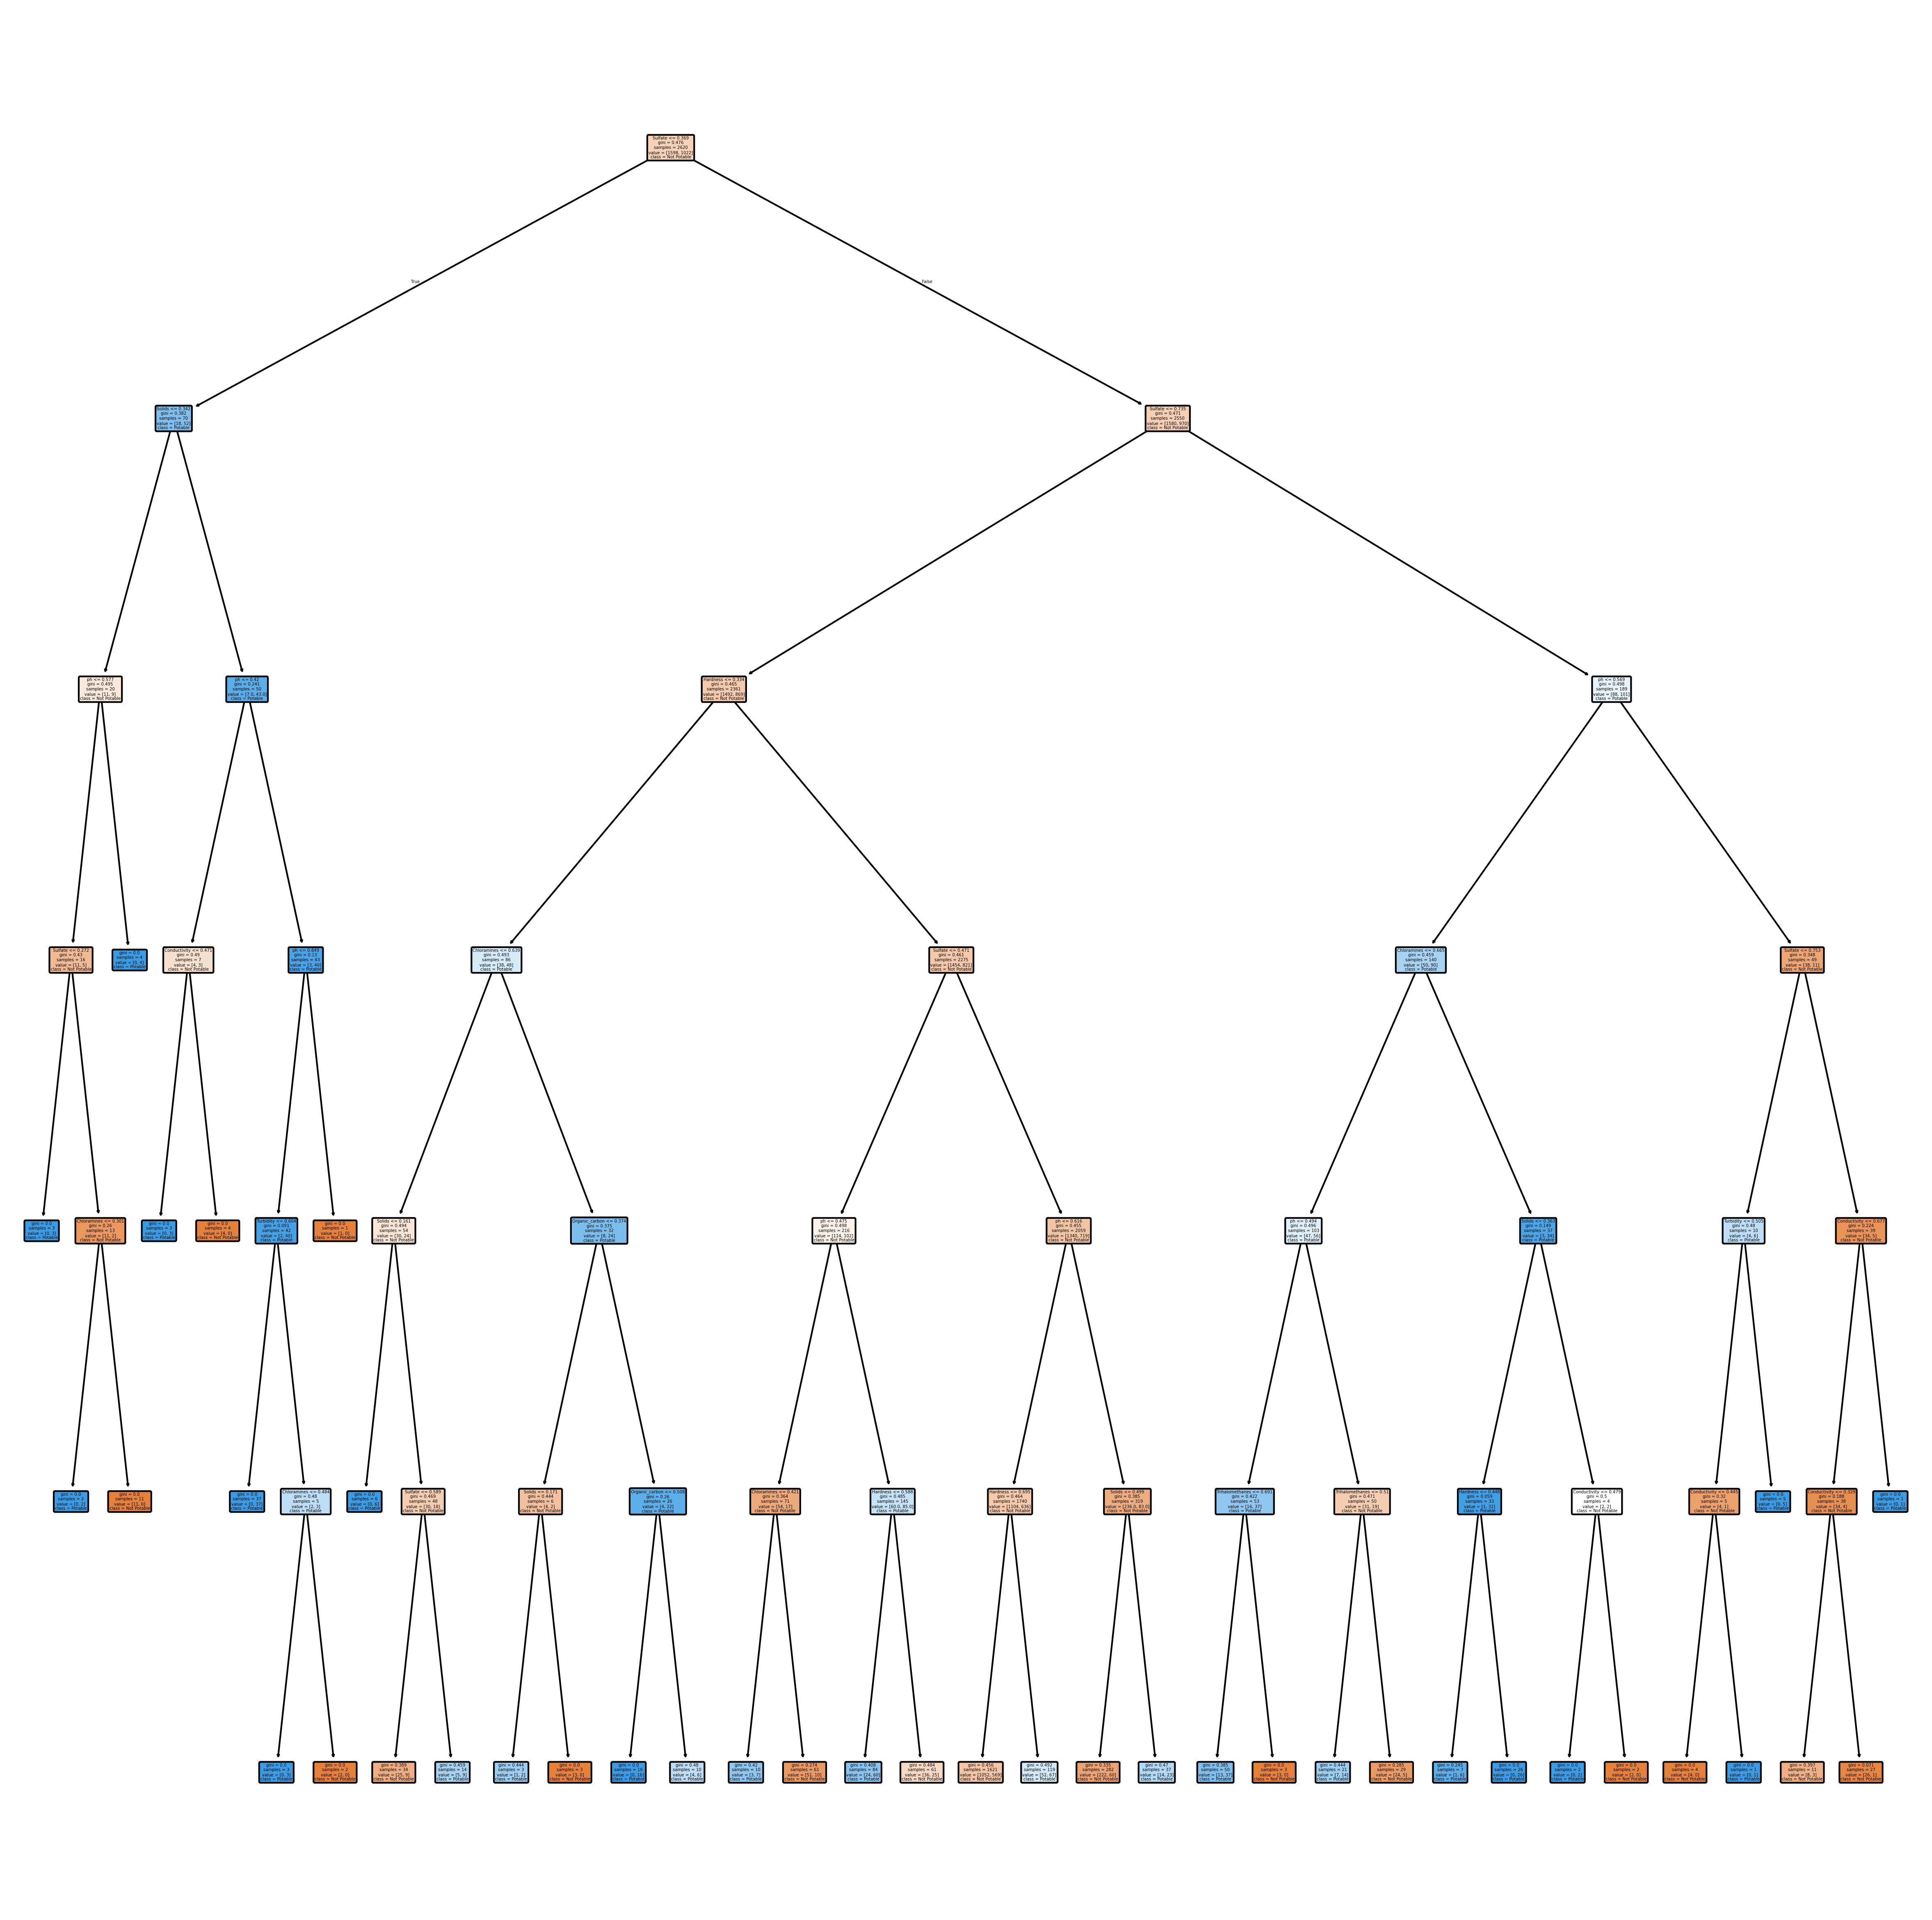

In [57]:
#Decision Tree
from sklearn import tree
import matplotlib.pyplot as plt

# Use the SAME feature names used during training
feature_names = list(train_df.drop(columns=['Potability']).columns)

plt.figure(figsize=(20, 20), dpi=300)

tree.plot_tree(
    clf,
    feature_names=feature_names,
    class_names=["Not Potable", "Potable"],
    filled=True,
    rounded=True
)

plt.show()

NameError: name 'jb' is not defined